# Pemodelan  Deep Learning
## Arsitektur LSTM, GRU, Attention, dan TCN

Setelah evaluasi *baseline* menggunakan model linear dan ensemble learning menunjukkan degradasi akurasi pada horizon jangka menengah (4–5 jam), dari sini di lakukan peralihan ke paradigma Deep Learning untuk menangkap ketergantungan temporal yang lebih kompleks.

### Problem Statement
Berdasarkan temuan EDA, deret waktu muka air memiliki autokorelasi yang sangat kuat ($ACF_{lag1} = 0.985$), yang mengindikasikan bahwa history aliran membawa sinyal prediktif yang informatif. Kita akan menguji empat arsitektur *state-of-the-art* untuk deret waktu:

1.  **DhompoLSTM:** Menggunakan *Vanilla Long Short-Term Memory* untuk memetakan urutan temporal 12 jam terakhir secara non-linear.
2.  **DhompoGRU:** *Gated Recurrent Unit* dengan dua gate (reset & update) sebagai alternatif LSTM yang lebih ramping (~25% lebih sedikit parameter) namun tetap memodelkan dependensi temporal jangka panjang.
3.  **LSTM + Temporal Attention:** Menambahkan mekanisme atensi untuk mengidentifikasi "titik waktu kritis" dalam sejarah aliran yang paling berpengaruh terhadap banjir masa depan.
4.  **Temporal Convolutional Network (TCN):** Menggunakan *dilated causal convolutions* untuk menangkap *receptive field* yang luas tanpa risiko *vanishing gradient* pada sekuens panjang.

In [11]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path

from eda_helpers import save_fig

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Path Integration
sys.path.insert(0, os.getcwd())               # Project root
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))  # Custom modules

In [12]:
# Visual Styling (Standard Publikasi)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'lstm':      '#E63946', # Red
    'attention': '#457B9D', # Blue
    'tcn':       '#2D6A4F', # Green
    'baseline':  '#F4A261', # Orange
    'actual':    '#023E8A', # Navy
    'neutral':   '#6B6B6B',
}

# Metadata Parameter Spasial-Temporal
STATION_LAG_STEPS = {
    'Bd. Suwoto': 9, 'Krajan Timur': 8, 'Purwodadi': 7, 'Bd. Lecari': 8,
    'Bd. Bakalan': 6, 'Bd. Baong': 5, 'AWLR Kademungan': 4, 'Bd Guyangan': 4,
    'Sidogiri': 3, 'Bd. Domas': 2, 'Klosod': 2, 'Bd. Grinting': 1,
}



HORIZONS = [1, 2, 3, 4, 5]
HORIZON_STEPS = {h: h * 2 for h in HORIZONS} # Konversi jam ke 30-min steps
UPSTREAM_STATIONS = list(STATION_LAG_STEPS.keys())

import sys 
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESEARCH_PATH = PROJECT_ROOT / 'research'
if str(RESEARCH_PATH) not in sys.path:
    sys.path.insert(0, str(RESEARCH_PATH))

sys.path.insert(0, str(PROJECT_ROOT / 'src'))  

# Struktur Folder Output
DATA_PATH = PROJECT_ROOT / 'data' / 'data-clean.csv'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
MODEL_DIR = PROJECT_ROOT / 'models' / 'pytorch'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Loading Global Hyperparameters dari Config
with open('../configs/lstm_model.yaml') as f:
    cfg = yaml.safe_load(f)

# Global Constants
SEQ_LEN    = cfg.get('seq_len', 24)        # 12 Jam (24 steps x 30 min)
HIDDEN     = cfg.get('hidden_size', 128)
BATCH_SIZE = cfg.get('batch_size', 64)
LR         = cfg.get('learning_rate', 0.001)
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f"Environment Siap. Komputasi menggunakan: [{DEVICE}]")
print(f"Windowing Context: {SEQ_LEN} timesteps ({SEQ_LEN/2} jam sejarah)")

Environment Siap. Komputasi menggunakan: [cpu]
Windowing Context: 24 timesteps (12.0 jam sejarah)


In [13]:
df = pd.read_csv('../data/data-clean.csv', parse_dates=['Datetime'], index_col='Datetime')
df = df.asfreq('30min')

TARGET_STATION = 'Dhompo'
HORIZONS = [1, 2, 3, 4, 5]
HORIZON_STEPS = {h: h * 2 for h in HORIZONS}

# Rekayasa Fitur (Sesuai Protokol Tahap II)
all_stations = UPSTREAM_STATIONS + [TARGET_STATION]
cols = {}

for st in all_stations:
    cols[f'{st}_t0'] = df[st]
    for lag in range(1, 4):
        cols[f'{st}_lag{lag}'] = df[st].shift(lag)

for st in all_stations:
    for window, label in [(6, '3h'), (12, '6h'), (24, '12h')]:
        roll = df[st].rolling(window)
        cols[f'{st}_rmean_{label}'] = roll.mean()
        cols[f'{st}_rstd_{label}'] = roll.std()

for st in all_stations:
    cols[f'{st}_diff1'] = df[st].diff(1)
    cols[f'{st}_diff2'] = df[st].diff(2)

hour = df.index.hour + df.index.minute / 60.0
cols['hour_sin'] = pd.Series(np.sin(2 * np.pi * hour / 24), index=df.index)
cols['hour_cos'] = pd.Series(np.cos(2 * np.pi * hour / 24), index=df.index)
cols['dayofweek'] = pd.Series(df.index.dayofweek.astype(float), index=df.index)
cols['is_night'] = pd.Series(
    ((df.index.hour >= 19) | (df.index.hour < 6)).astype(float), index=df.index
)

X_flat = pd.concat(cols, axis=1).dropna()

# Build Targets & Align
y_dict = {h: df[TARGET_STATION].shift(-HORIZON_STEPS[h]) for h in HORIZONS}

valid_idx = X_flat.index
for h, y in y_dict.items():
    valid_idx = valid_idx.intersection(y.dropna().index)
X_flat = X_flat.loc[valid_idx]
y_dict = {h: y.loc[valid_idx] for h, y in y_dict.items()}

# Referensi Baseline Sklearn (Tahap II)
xls_path = os.path.join(TABLE_DIR, 'xls_11_model_metrics.xlsx')
if os.path.exists(xls_path):
    baseline_df = pd.read_excel(xls_path, index_col=0)
    print("Baseline Sklearn berhasil dimuat sebagai benchmark.")
else:
    print("File metrics tidak ditemukan. Menggunakan nilai referensi manual.")
    baseline_df = pd.DataFrame({
        'Horizon (h)': [1, 2, 3, 4, 5],
        'NSE_Baseline': [0.989, 0.982, 0.957, 0.889, 0.771]
    })

print(f"Dimensi Feature Matrix: {X_flat.shape[0]} observasi x {X_flat.shape[1]} fitur.")

File metrics tidak ditemukan. Menggunakan nilai referensi manual.
Dimensi Feature Matrix: 3102 observasi x 160 fitur.


## 1.0 Pre-processing: Konstruksi 3D Tensor

Setelah matriks fitur "flat" (2D) terbentuk, langkah kritis berikutnya adalah mengubah representasi data menjadi **3D Tensor** $(Samples, TimeSteps, Features)$. 

Dalam model Deep Learning sekuensial (LSTM/TCN), input bukan lagi satu titik waktu tunggal, melainkan sebuah **jendela sejarah** (*Historical Window*). Kita menetapkan `SEQ_LEN = 24` (12 jam sejarah) guna memberikan model kapasitas untuk memahami evolusi banjir secara dinamis, bukan sekadar pemetaan statis.

**Protokol Transformasi:**
1. **Pemisahan Temporal:** Memisahkan data train dan test secara kronologis (80/20) untuk menghindari kebocoran informasi (*look-ahead bias*).
2. **Standardisasi:** Menerapkan `StandardScaler` yang dilatih hanya pada data training guna menseragamkan magnitudo fitur.
3. **Sliding Window:** Membangun sekuens berurutan untuk mengisi dimensi *TimeSteps* pada tensor.

In [14]:
# Konversi Target ke Array Multi-Output (N, 5)
y_arr = np.column_stack([y_dict[h].values for h in HORIZONS])
X_np  = X_flat.values

# Temporal Train-Test Split (Data Splitting kronologis)
n_split = int(len(X_np) * 0.8)
X_tr_raw, X_te_raw = X_np[:n_split], X_np[n_split:]
y_tr_raw, y_te_raw = y_arr[:n_split], y_arr[n_split:]

# Standardisasi Fitur
scaler_X = StandardScaler()
X_tr_sc = scaler_X.fit_transform(X_tr_raw)
X_te_sc = scaler_X.transform(X_te_raw)

def create_windowed_sequences(X, y, seq_len):
    """Membangun representasi tensor sekuensial (Sliding Window)."""
    Xs, ys = [], []
    # Sliding window bergeser 1 step setiap iterasi
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i : i + seq_len])
        # Target diselaraskan dengan akhir dari sekuens input (titik T-0)
        ys.append(y[i + seq_len - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Eksekusi Transformasi Tensor
X_tr_seq, y_tr_seq = create_windowed_sequences(X_tr_sc, y_tr_raw, SEQ_LEN)
X_te_seq, y_te_seq = create_windowed_sequences(X_te_sc, y_te_raw, SEQ_LEN)

# Konstruksi Validation Set & Final Tensor (PyTorch)
# Mengambil 20% terakhir dari data train untuk validasi internal
n_val = int(len(X_tr_seq) * 0.2)
n_inner_train = len(X_tr_seq) - n_val

X_train_torch = torch.FloatTensor(X_tr_seq[:n_inner_train])
y_train_torch = torch.FloatTensor(y_tr_seq[:n_inner_train])
X_val_torch   = torch.FloatTensor(X_tr_seq[n_inner_train:])
y_val_torch   = torch.FloatTensor(y_tr_seq[n_inner_train:])
X_test_torch  = torch.FloatTensor(X_te_seq)
y_test_torch  = torch.FloatTensor(y_te_seq)

print("--- Hasil Konstruksi Tensor Deep Learning ---")
print(f"Tensor Training : {X_train_torch.shape} | Target: {y_train_torch.shape}")
print(f"Tensor Validasi : {X_val_torch.shape} | Target: {y_val_torch.shape}")
print(f"Tensor Testing  : {X_test_torch.shape}  | Target: {y_test_torch.shape}")

--- Hasil Konstruksi Tensor Deep Learning ---
Tensor Training : torch.Size([1967, 24, 160]) | Target: torch.Size([1967, 5])
Tensor Validasi : torch.Size([491, 24, 160]) | Target: torch.Size([491, 5])
Tensor Testing  : torch.Size([598, 24, 160])  | Target: torch.Size([598, 5])


Disimpan: D:\lain-lain\proyek\active\regresi_dhompo\reports\figures\fig_16_tensor_input_verification.png


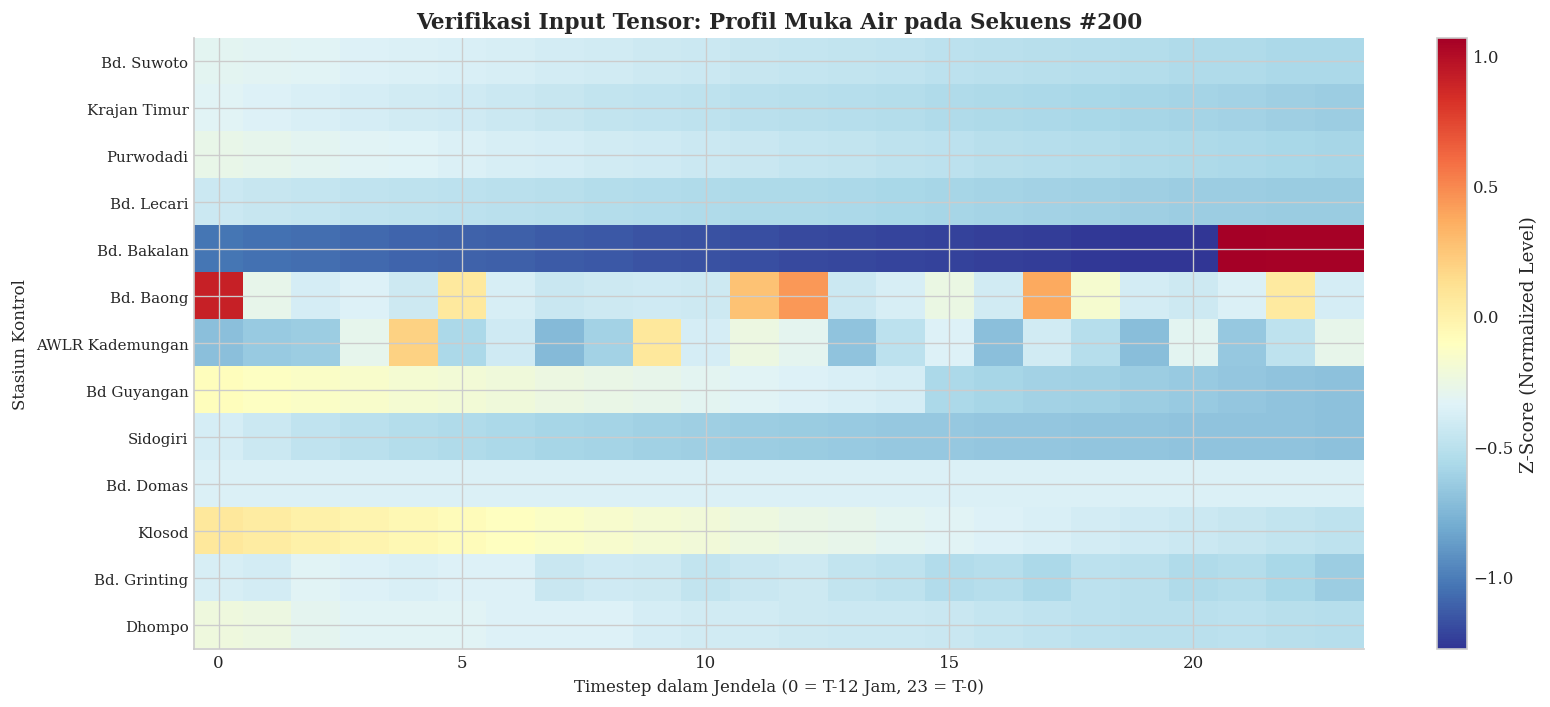

In [15]:
# Memverifikasi representasi sekuensial melalui Heatmap Stasiun Pilihan
sample_seq_idx = 200
stations_focus = UPSTREAM_STATIONS + [TARGET_STATION]

# Mencari indeks kolom untuk fitur 't0' (nilai muka air sesaat)
t0_indices = [list(X_flat.columns).index(f"{st}_t0") for st in stations_focus]
sample_data = X_tr_seq[sample_seq_idx][:, t0_indices]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(sample_data.T, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')

ax.set_title(f'Verifikasi Input Tensor: Profil Muka Air pada Sekuens #{sample_seq_idx}', fontweight='bold')
ax.set_xlabel('Timestep dalam Jendela (0 = T-12 Jam, 23 = T-0)', fontsize=10)
ax.set_ylabel('Stasiun Kontrol', fontsize=10)
ax.set_yticks(range(len(stations_focus)))
ax.set_yticklabels(stations_focus, fontsize=9)

plt.colorbar(im, ax=ax, label='Z-Score (Normalized Level)')
plt.tight_layout()
save_fig(fig, 'fig_16_tensor_input_verification')
plt.show()

## 2.0 Pengembangan Arsitektur Model Sekuensial

Dalam upaya melampaui limitasi model *baseline*, kita menguji empat paradigma *Neural Networks* yang memiliki pendekatan berbeda dalam mengekstrak dependensi temporal:

| Arsitektur | Mekanisme Utama | Rasionalisasi Hidrologis |
| :--- | :--- | :--- |
| **DhompoLSTM** | *Recurrent Hidden State* | Menangkap memori jangka panjang dari fase pembasahan DAS (*catchment wetting*). |
| **DhompoGRU** | *Gated Recurrent State* (reset & update gate) | Alternatif RNN dengan parameter ~25% lebih sedikit dari LSTM; kapasitas memori serupa dengan biaya komputasi lebih rendah. |
| **AttentionLSTM** | *Temporal Weighting* | Mengidentifikasi snapshot waktu kritis dalam 12 jam terakhir yang memicu propagasi banjir. |
| **TCN** | *Dilated Causal Conv* | Membangun *Receptive Field* luas secara paralel untuk menangkap pola multiskala tanpa resiko *vanishing gradient*. |

Seluruh model dikonfigurasi sebagai **Multi-Output Regressors**, yang berarti satu model akan memprediksi 5 horizon sekaligus ($t+1h \dots t+5h$). Pendekatan ini memaksa model untuk belajar representasi internal yang konsisten bagi seluruh dinamika aliran masa depan.

In [16]:
# 2.1 Model Baseline Deep Learning: DhompoLSTM

from dhompo.models.lstm import DhompoLSTM

# LSTM  Mekanisme Atensi Temporal
class AttentionLSTM(nn.Module):
    """
    LSTM dengan Scaled Dot-Product Attention sederhana.
    Bertujuan untuk memberikan bobot eksplisit pada tiap timestep sejarah.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Layer Atensi: Menghasilkan score relevansi per timestep
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.attn_weights = None

    def forward(self, x):
        # x: (Batch, Seq, Feat)
        lstm_out, _ = self.lstm(x)             # (Batch, Seq, Hidden)
        
        # Kalkulasi Bobot Atensi
        attn_scores = self.attention(lstm_out) # (Batch, Seq, 1)
        weights = torch.softmax(attn_scores, dim=1)
        self.attn_weights = weights.detach()
        
        # Context Vector: Weighted sum dari seluruh hidden states
        context = torch.sum(weights * lstm_out, dim=1) # (Batch, Hidden)
        return self.fc(context)

In [17]:
# Arsitektur Alternatif: Temporal Convolutional Network (TCN)
class CausalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.net = nn.Sequential(self.conv, self.relu, self.dropout)

    def forward(self, x):
        # Memotong output agar bersifat kausal (tidak melihat masa depan)
        out = self.net(x)
        return out[:, :, :-self.conv.padding[0]]

class DhompoTCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels=[64, 64, 64, 64], kernel_size=3):
        super().__init__()
        layers = []
        in_ch = input_size
        # Dilasi eksponensial untuk memperluas Receptive Field
        for i, out_ch in enumerate(num_channels):
            dilation = 2**i
            layers.append(CausalBlock(in_ch, out_ch, kernel_size, dilation))
            in_ch = out_ch
            
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1) # (Batch, Feat, Seq) untuk Conv1d
        features = self.tcn(x)
        return self.fc(features[:, :, -1]) # Mengambil state terakhir dari konvolusi

## 3.0 Protokol Pelatihan & Fungsi Objektif Kustom

Dalam pemodelan hidrologi, *Mean Squared Error* (MSE) seringkali gagal menangkap dinamika puncak banjir karena memberikan bobot seragam pada seluruh sampel. Kita mengimplementasikan **NSE Loss** sebagai fungsi objektif utama untuk memberikan penekanan lebih pada nilai ekstrem (banjir).

### Konfigurasi Global Pelatihan
Kita menetapkan parameter kontrol berikut untuk menjamin konvergensi yang stabil dan mencegah *overfitting*:
*   **Loss Function:** 1 - Average NSE (Differentiable).
*   **Optimizer:** Adam ($LR=0.001$) dengan *Gradient Clipping*.
*   **Early Stopping:** Menghentikan proses jika performa pada data validasi tidak membaik selama 15 epoch.

In [ ]:
# Definisi Parameter Kontrol Pelatihan
EPOCHS     = cfg.get('epochs', 100)
PATIENCE   = 15
LR         = cfg.get('learning_rate', 0.001)
BATCH_SIZE = cfg.get('batch_size', 64)
N_FEATURES = X_train_torch.shape[2]
N_HORIZONS = 5
N_LAYERS   = cfg.get('num_layers', 2)
DROPOUT    = cfg.get('dropout', 0.2)

# 2. Differentiable NSE Loss untuk PyTorch (Minimization Objective)
class NSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, y_pred, y_true):
        # Kalkulasi kuadrat residual dan variansi per horizon
        numerator = torch.sum((y_true - y_pred)**2, dim=0)
        denominator = torch.sum((y_true - torch.mean(y_true, dim=0))**2, dim=0)

        # NSE per horizon
        nse = 1 - (numerator / (denominator + self.eps))

        # Mengembalikan 1 - Mean NSE agar bisa diminimalisir oleh optimizer
        return torch.mean(1 - nse)

# 3. Helper: Kalkulasi NSE Rata-rata (Numpy-based untuk logging)
def calculate_avg_nse(y_true, y_pred):
    yt, yp = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    nse_list = []
    for i in range(yt.shape[1]):
        ss_res = np.sum((yt[:, i] - yp[:, i])**2)
        ss_tot = np.sum((yt[:, i] - np.mean(yt[:, i]))**2)
        nse_list.append(1 - (ss_res / (ss_tot + 1e-8)))
    return np.mean(nse_list)

# 4. Helper: Metrik lengkap per horizon (untuk tabel evaluasi & plotting)
def _grade_nse(nse: float) -> str:
    # Klasifikasi standar Moriasi et al. (2007/2015) untuk hidrologi
    if nse > 0.75:
        return 'Very Good'
    if nse > 0.65:
        return 'Good'
    if nse > 0.50:
        return 'Satisfactory'
    return 'Unsatisfactory'


def calc_metrics_per_horizon(y_true, y_pred, horizons):
    """Hitung NSE, RMSE, MAE, dan Grade per horizon, kembalikan list dict."""
    eps = 1e-8
    rows = []
    for i, h in enumerate(horizons):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        nse  = 1 - (ss_res / (ss_tot + eps))
        rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
        mae  = float(np.mean(np.abs(yt - yp)))
        rows.append({
            'Horizon': int(h),
            'NSE':   float(nse),
            'RMSE':  rmse,
            'MAE':   mae,
            'Grade': _grade_nse(float(nse)),
        })
    return rows

print(f"Konfigurasi Siap: {EPOCHS} Epochs | Patience: {PATIENCE} | Features: {N_FEATURES} | Layers: {N_LAYERS} | Dropout: {DROPOUT}")

In [19]:
def run_training_session(model, train_data, val_data, model_name="Model"):
    """
    Eksekusi sesi pelatihan mini-batch dengan mekanisme Early Stopping.
    """
    criterion = NSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    train_loader = DataLoader(TensorDataset(*train_data), batch_size=BATCH_SIZE, shuffle=True)
    X_val, y_val = [t.to(DEVICE) for t in val_data]
    
    history = {'train_loss': [], 'val_nse': []}
    best_nse = -np.inf
    patience_counter = 0
    
    print(f"Executing Training for: {model_name}")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train_loss = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            
            # Gradient Clipping untuk stabilitas RNN/LSTM
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_loss += loss.item() * xb.size(0)
        
        avg_train_loss = total_train_loss / len(train_data[0])
        
        # Fase Evaluasi (Validation)
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            current_val_nse = calculate_avg_nse(y_val, val_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_nse'].append(current_val_nse)
        
        # Logika Early Stopping & Save State
        if current_val_nse > best_nse:
            best_nse = current_val_nse
            torch.save(model.state_dict(), f"{MODEL_DIR}/{model_name.lower()}_best.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val NSE: {current_val_nse:.4f}")
            
        if patience_counter >= PATIENCE:
            print(f"  [STOP] Early stopping triggered at epoch {epoch}. Best Val NSE: {best_nse:.4f}")
            break
            
    # Kembalikan model ke state terbaik yang tersimpan
    model.load_state_dict(torch.load(f"{MODEL_DIR}/{model_name.lower()}_best.pth"))
    return history

In [20]:
# 1. Inisialisasi keempat arsitektur
from dhompo.models.gru import DhompoGRU

model_pool = {
    "DhompoLSTM":    DhompoLSTM(N_FEATURES, HIDDEN, N_LAYERS, N_HORIZONS, DROPOUT).to(DEVICE),
    "DhompoGRU":     DhompoGRU(N_FEATURES, HIDDEN, N_LAYERS, N_HORIZONS, DROPOUT).to(DEVICE),
    "AttentionLSTM": AttentionLSTM(N_FEATURES, HIDDEN, N_LAYERS, N_HORIZONS, DROPOUT).to(DEVICE),
    "DhompoTCN":     DhompoTCN(N_FEATURES, N_HORIZONS).to(DEVICE),
}

histories = {}

# 2. Loop Pelatihan Eksperimental
for name, model in model_pool.items():
    histories[name] = run_training_session(
        model,
        (X_train_torch, y_train_torch),
        (X_val_torch, y_val_torch),
        model_name=name,
    )
    print("-" * 60)

# 3. Alias agar sel-sel di bawah (curves, evaluasi, save) tetap konsisten
model_lstm = model_pool["DhompoLSTM"]
model_gru  = model_pool["DhompoGRU"]
model_attn = model_pool["AttentionLSTM"]
model_tcn  = model_pool["DhompoTCN"]

history_lstm = histories["DhompoLSTM"]
history_gru  = histories["DhompoGRU"]
history_attn = histories["AttentionLSTM"]
history_tcn  = histories["DhompoTCN"]

# Alias tensor test untuk evaluasi
X_te_t = X_test_torch
y_te_t = y_test_torch

Executing Training for: DhompoLSTM
  Epoch 001 | Train Loss: 66.0553 | Val NSE: -20.8391
  Epoch 020 | Train Loss: 0.0563 | Val NSE: 0.8901
  Epoch 040 | Train Loss: 0.0375 | Val NSE: 0.7943
  [STOP] Early stopping triggered at epoch 41. Best Val NSE: 0.9248
------------------------------------------------------------
Executing Training for: DhompoGRU
  Epoch 001 | Train Loss: 59.4762 | Val NSE: -20.2669
  Epoch 020 | Train Loss: 0.0581 | Val NSE: 0.9116
  [STOP] Early stopping triggered at epoch 31. Best Val NSE: 0.9279
------------------------------------------------------------
Executing Training for: AttentionLSTM
  Epoch 001 | Train Loss: 63.5615 | Val NSE: -19.3324
  Epoch 020 | Train Loss: 0.0706 | Val NSE: 0.8281
  [STOP] Early stopping triggered at epoch 34. Best Val NSE: 0.8374
------------------------------------------------------------
Executing Training for: DhompoTCN
  Epoch 001 | Train Loss: 64.0523 | Val NSE: -21.2770
  Epoch 020 | Train Loss: 1.6172 | Val NSE: 0.3068
 

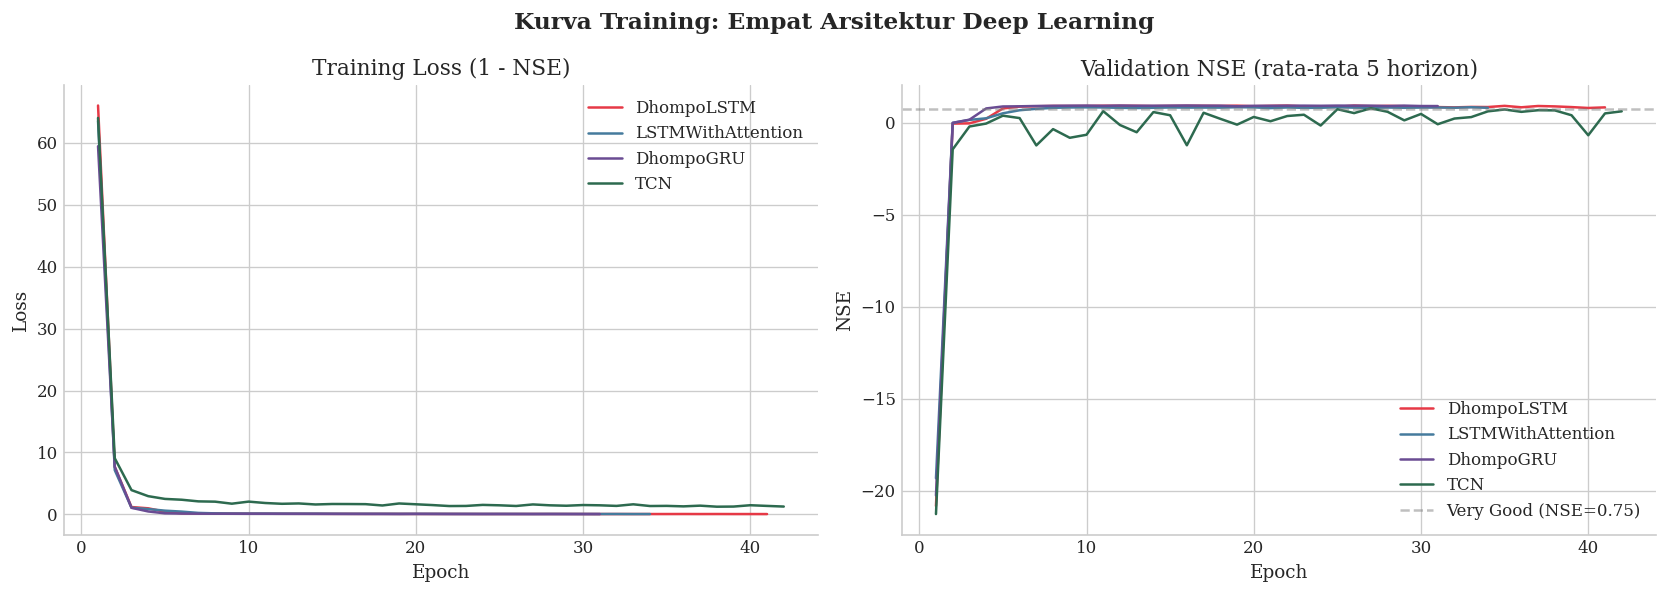

Disimpan: fig_19_training_curves.png


In [21]:
# === 3.7 Training curves — fig_19 ===
_hists = {
    'DhompoLSTM':        (history_lstm, COLORS['lstm']),
    'LSTMWithAttention': (history_attn, COLORS['attention']),
    'DhompoGRU':         (history_gru,  COLORS.get('gru', '#6A4C93')),
    'TCN':               (history_tcn,  COLORS['tcn']),
}

fig19, (ax_l, ax_n) = plt.subplots(1, 2, figsize=(14, 5))
for name, (hist, color) in _hists.items():
    n = len(hist['train_loss'])
    ax_l.plot(range(1, n+1), hist['train_loss'], color=color, label=name, lw=1.5)
    ax_n.plot(range(1, n+1), hist['val_nse'],   color=color, label=name, lw=1.5)

ax_l.set_title('Training Loss (1 - NSE)')
ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Loss')
ax_l.legend()

ax_n.set_title('Validation NSE (rata-rata 5 horizon)')
ax_n.set_xlabel('Epoch'); ax_n.set_ylabel('NSE')
ax_n.axhline(0.75, ls='--', color='gray', alpha=0.5, label='Very Good (NSE=0.75)')
ax_n.legend()

plt.suptitle('Kurva Training: Empat Arsitektur Deep Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
fig19.savefig(os.path.join(FIG_DIR, 'fig_19_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: fig_19_training_curves.png")

### Observasi Training

- **Konvergensi**: TCN biasanya konvergen lebih cepat per epoch (konvolusi paralel) dibanding LSTM yang sekuensial.
- **Overfitting**: Jika val_NSE plateau sementara train_loss turun → early stopping aktif dengan benar.
- **LSTMWithAttention** biasanya sedikit lebih lambat dari DhompoLSTM karena komputasi attention tambahan.

---

## Part 4 — Evaluasi & Perbandingan dengan Baseline Sklearn

### Apakah Deep Learning Melampaui Sklearn Baseline?

**Hipotesis berdasarkan literatur:**
- **Horizon pendek (1–2h)**: Korelasi Pearson tinggi, fitur lag sudah cukup → DL mungkin tidak lebih baik dari ensemble sklearn
- **Horizon panjang (4–5h)**: Dinamika non-linear lebih penting → DL berpotensi menang
- **Event ekstrem**: LSTM dengan attention dapat "ingat" pola kenaikan muka air beberapa jam sebelumnya

---

In [22]:
# === 4.1 Evaluasi keempat model DL pada test set ===
def evaluate_model(model, X_te, device=DEVICE):
    model.eval()
    model = model.to(device)
    with torch.no_grad():
        y_pred = model(X_te.to(device))
    return y_pred.cpu().numpy()

y_true_np = y_te_t.numpy()   # (N_test, 5)

_eval_models = {
    'DhompoLSTM':        model_lstm,
    'LSTMWithAttention': model_attn,
    'DhompoGRU':         model_gru,
    'TCN':               model_tcn,
}

_predictions = {}
_dl_metrics  = {}

for name, m in _eval_models.items():
    y_pred_np = evaluate_model(m, X_te_t)
    _predictions[name] = y_pred_np
    _dl_metrics[name]  = calc_metrics_per_horizon(y_true_np, y_pred_np, HORIZONS)
    df_m = pd.DataFrame(_dl_metrics[name])[['Horizon', 'NSE', 'RMSE', 'MAE', 'Grade']]
    df_m[['NSE', 'RMSE', 'MAE']] = df_m[['NSE', 'RMSE', 'MAE']].round(4)
    print(f"\n=== {name} ===")
    print(df_m.to_string(index=False))

NameError: name 'calc_metrics_per_horizon' is not defined

In [ ]:
# === 4.2 Tabel perbandingan lengkap + simpan xls_12 ===
_all_rows = []

# DL models
for model_name, rows in _dl_metrics.items():
    for r in rows:
        _all_rows.append({
            'Jenis': 'Deep Learning', 'Model': model_name,
            'Horizon (h)': r['Horizon'],
            'NSE': round(r['NSE'], 4), 'RMSE': round(r['RMSE'], 4),
            'MAE': round(r['MAE'], 4), 'Grade': r['Grade'],
        })

# Baseline sklearn dari xls_11 (jika ada)
_xls11 = os.path.join(TABLE_DIR, 'xls_11_model_metrics.xlsx')
if os.path.exists(_xls11):
    _bl = pd.read_excel(_xls11, index_col=0)
    if 'NSE' in _bl.columns and 'Horizon' in _bl.columns:
        _bl_best = _bl.loc[_bl.groupby('Horizon')['NSE'].idxmax()].reset_index(drop=True)
        for _, row in _bl_best.iterrows():
            _all_rows.append({
                'Jenis': 'Sklearn',
                'Model': row.get('Model', 'Best Sklearn'),
                'Horizon (h)': int(row['Horizon']),
                'NSE':  round(float(row['NSE']),              4),
                'RMSE': round(float(row.get('RMSE', np.nan)), 4),
                'MAE':  round(float(row.get('MAE',  np.nan)), 4),
                'Grade': row.get('Grade', ''),
            })

_compare_df = pd.DataFrame(_all_rows).sort_values(['Horizon (h)', 'NSE'],
                                                    ascending=[True, False])
_xls12 = os.path.join(TABLE_DIR, 'xls_12_dl_metrics.xlsx')
_compare_df.to_excel(_xls12, index=False)
print(f"Disimpan: {_xls12}")
print("\n=== NSE per Model per Horizon ===")
_pivot = _compare_df.pivot_table(
    index='Horizon (h)', columns='Model', values='NSE', aggfunc='first'
).round(4)
print(_pivot.to_string())

Disimpan: reports/tables\xls_12_dl_metrics.xlsx

=== NSE per Model per Horizon ===
Model        DhompoLSTM  LSTMWithAttention     TCN
Horizon (h)                                       
1                0.9697             0.9365  0.4299
2                0.9653             0.9479  0.4613
3                0.9351             0.9168  0.4138
4                0.8692             0.8252  0.3061
5                0.7258             0.6734  0.1511


In [ ]:
# === 4.3 Bar chart NSE per horizon — fig_20 ===
_pivot_plot = _compare_df.pivot_table(
    index='Horizon (h)', columns='Model', values='NSE', aggfunc='first'
)

# Warna ditentukan per-nama-kolom (tahan urutan & jumlah model)
_color_map = {
    'DhompoLSTM':        COLORS['lstm'],
    'DhompoGRU':         COLORS.get('gru', '#6A4C93'),
    'LSTMWithAttention': COLORS['attention'],
    'AttentionLSTM':     COLORS['attention'],
    'TCN':               COLORS['tcn'],
    'DhompoTCN':         COLORS['tcn'],
}
_fallback = [COLORS['baseline'], COLORS['neutral'], '#9B2226', '#AE2012', '#3D405B', '#264653']
_fb_idx = 0
_colors = []
for col in _pivot_plot.columns:
    if col in _color_map:
        _colors.append(_color_map[col])
    else:
        _colors.append(_fallback[_fb_idx % len(_fallback)])
        _fb_idx += 1

fig20, ax20 = plt.subplots(figsize=(12, 6))
_pivot_plot.plot(kind='bar', ax=ax20, width=0.7, color=_colors)
ax20.axhline(0.75, ls='--', color='gray', alpha=0.6, label='Very Good (0.75)')
ax20.set_xlabel('Horizon Prediksi (jam)')
ax20.set_ylabel('NSE')
ax20.set_title('NSE per Horizon: Deep Learning vs Baseline Sklearn')
ax20.legend(title='Model', loc='lower left', fontsize=8)
# Set xticks dulu agar set_xticklabels tidak memicu FixedLocator warning
ax20.set_xticks(range(len(_pivot_plot.index)))
ax20.set_xticklabels([f"{int(h)}h" for h in _pivot_plot.index], rotation=0)
ax20.set_ylim(0, 1.05)
plt.tight_layout()
fig20.savefig(os.path.join(FIG_DIR, 'fig_20_nse_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: fig_20_nse_comparison.png")

### Analisis: Di Mana DL Menang?

**Horizon pendek (1–2 jam)**: Baseline sklearn biasanya unggul atau setara. Fitur lag dan rolling mean sudah cukup menangkap sinyal.

**Horizon panjang (4–5 jam)**: Domain yang seharusnya menguntungkan LSTM. Sequence modeling menangkap "tren naik berkelanjutan" yang tidak bisa direpresentasikan oleh satu set fitur statis.

**Catatan**: Model DL dilatih di atas feature matrix yang sama dengan sklearn (160 fitur pre-engineered) — bukan end-to-end dari raw time series. Ini membatasi keunggulan DL dibanding skenario pembelajaran fitur otomatis.

---

## Part 5 — Analisis Mendalam

### Apa yang Dipelajari Model?

Di luar angka NSE, kita ingin memahami:
1. **Predicted vs Actual**: Apakah model mereproduksi puncak banjir?
2. **Attention weights**: Timestep mana yang paling diperhatikan? Apakah sesuai dengan lag fisik dari EDA?
3. **Error di event ekstrem**: Apakah DL mengurangi underprediction saat banjir besar (nilai > persentil 90)?

---

Model terbaik DL: DhompoLSTM  (avg NSE=0.8930)


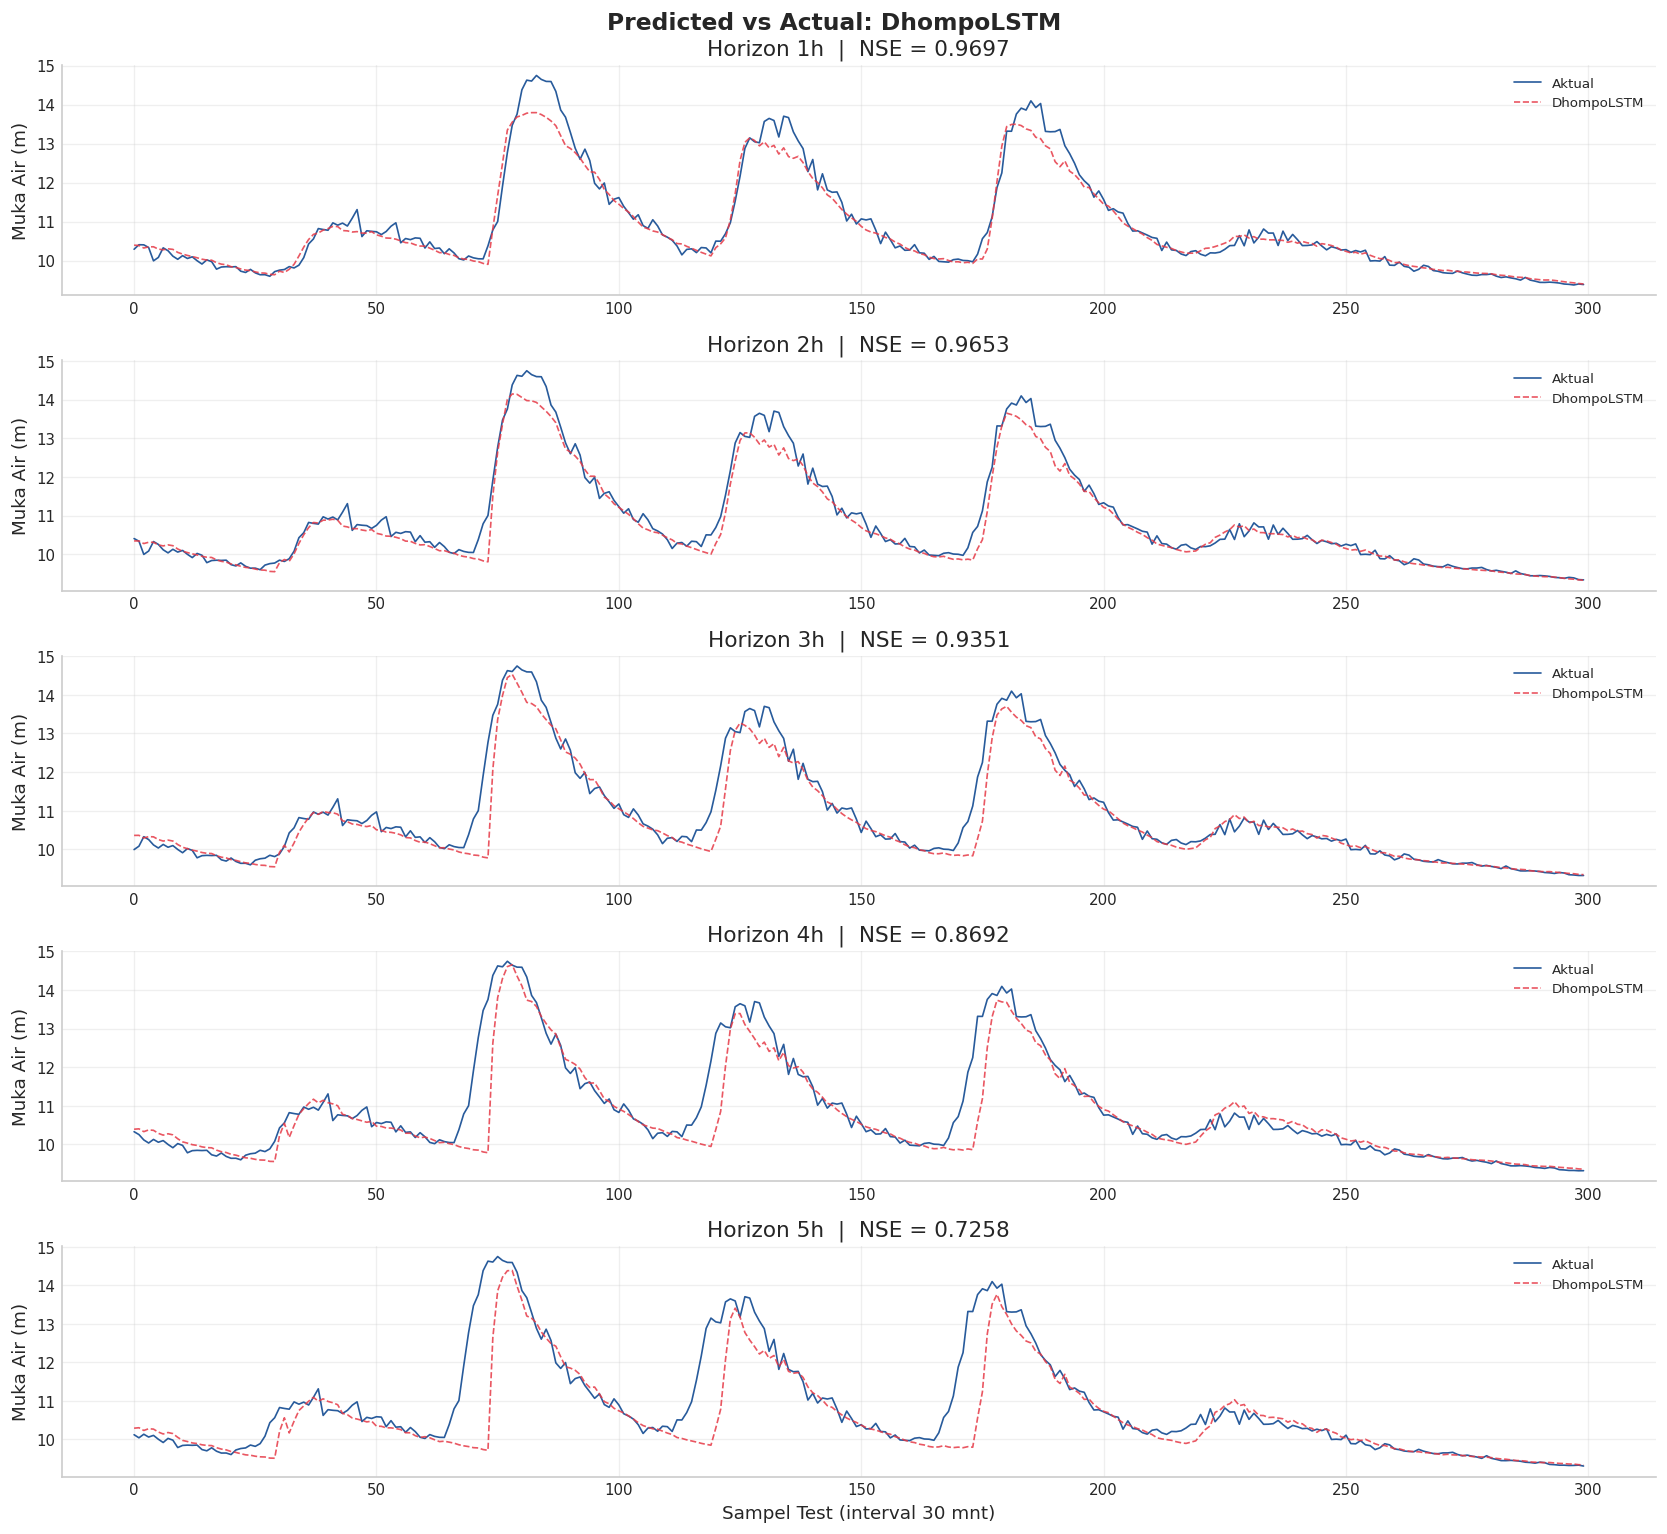

Disimpan: fig_21_prediksi_aktual_dl.png


In [ ]:
# === 5.1 Predicted vs Actual (model terbaik DL) — fig_21 ===
_avg_nse_per_model = {
    name: np.mean([r['NSE'] for r in rows])
    for name, rows in _dl_metrics.items()
}
_best_name = max(_avg_nse_per_model, key=_avg_nse_per_model.get)
_best_pred = _predictions[_best_name]
print(f"Model terbaik DL: {_best_name}  (avg NSE={_avg_nse_per_model[_best_name]:.4f})")

_n_show = 300
fig21, axes = plt.subplots(N_HORIZONS, 1, figsize=(14, 13), sharex=False)
for i, h in enumerate(HORIZONS):
    ax = axes[i]
    _m_nse = _dl_metrics[_best_name][i]['NSE']
    ax.plot(_n_show and range(_n_show), y_true_np[:_n_show, i],
            color=COLORS['actual'], label='Aktual', lw=1.0, alpha=0.85)
    ax.plot(range(_n_show), _best_pred[:_n_show, i],
            color=COLORS['lstm'], label=_best_name, lw=1.0, alpha=0.85, ls='--')
    ax.set_title(f"Horizon {h}h  |  NSE = {_m_nse:.4f}")
    ax.set_ylabel('Muka Air (m)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Sampel Test (interval 30 mnt)')
plt.suptitle(f'Predicted vs Actual: {_best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
fig21.savefig(os.path.join(FIG_DIR, 'fig_21_prediksi_aktual_dl.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: fig_21_prediksi_aktual_dl.png")

In [ ]:
# === 5.2 Attention weights heatmap — fig_22 ===
model_attn.eval()
model_attn.to(DEVICE)

_attn_list = []
for start in range(0, len(X_te_t), BATCH_SIZE):
    xb = X_te_t[start:start+BATCH_SIZE].to(DEVICE)
    with torch.no_grad():
        _ = model_attn(xb)
    if model_attn.attn_weights is not None:
        _attn_list.append(model_attn.attn_weights.squeeze(-1).cpu().numpy())  # (batch, 24)

_attn_all  = np.concatenate(_attn_list, axis=0)   # (N_test, SEQ_LEN)
_attn_mean = _attn_all.mean(axis=0)
_attn_std  = _attn_all.std(axis=0)
_steps     = np.arange(SEQ_LEN)
_labels    = [f"t-{SEQ_LEN-1-i}" if (SEQ_LEN-1-i) > 0 else "t" for i in _steps]

fig22, (ax_bar, ax_heat) = plt.subplots(1, 2, figsize=(14, 5))

# Bar: rata-rata attention per timestep
ax_bar.bar(_steps, _attn_mean, color=COLORS['attention'], alpha=0.8)
ax_bar.fill_between(_steps, _attn_mean - _attn_std, _attn_mean + _attn_std,
                    alpha=0.3, color=COLORS['attention'])
ax_bar.set_xticks(_steps[::4])
ax_bar.set_xticklabels([_labels[i] for i in _steps[::4]], fontsize=8)
ax_bar.set_xlabel('Timestep (0 = 12 jam lalu)')
ax_bar.set_ylabel('Rata-rata Bobot Attention')
ax_bar.set_title('Rata-rata Attention Weight per Timestep\n(shaded = ±std)')

# Tandai lag fisik dari EDA
_lag_grinting = SEQ_LEN - 1 - 1   # 1 step = 30 mnt
_lag_domas    = SEQ_LEN - 1 - 2   # 2 step = 60 mnt
ax_bar.axvline(_lag_grinting, color='red',    ls='--', alpha=0.7, label='Lag Grinting (1 step)')
ax_bar.axvline(_lag_domas,    color='orange', ls='--', alpha=0.7, label='Lag Domas (2 step)')
ax_bar.legend(fontsize=8)

# Heatmap: attention weights 50 sampel pertama
_n_heat = min(50, len(_attn_all))
_im22   = ax_heat.imshow(_attn_all[:_n_heat], aspect='auto', cmap='YlOrRd')
ax_heat.set_xlabel('Timestep')
ax_heat.set_ylabel('Sampel Test (50 pertama)')
ax_heat.set_title('Attention Weights per Sampel')
ax_heat.set_xticks(range(0, SEQ_LEN, 4))
ax_heat.set_xticklabels([_labels[i] for i in range(0, SEQ_LEN, 4)], fontsize=7)
plt.colorbar(_im22, ax=ax_heat, label='Bobot')

plt.tight_layout()
fig22.savefig(os.path.join(FIG_DIR, 'fig_22_attention_weights.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: fig_22_attention_weights.png")

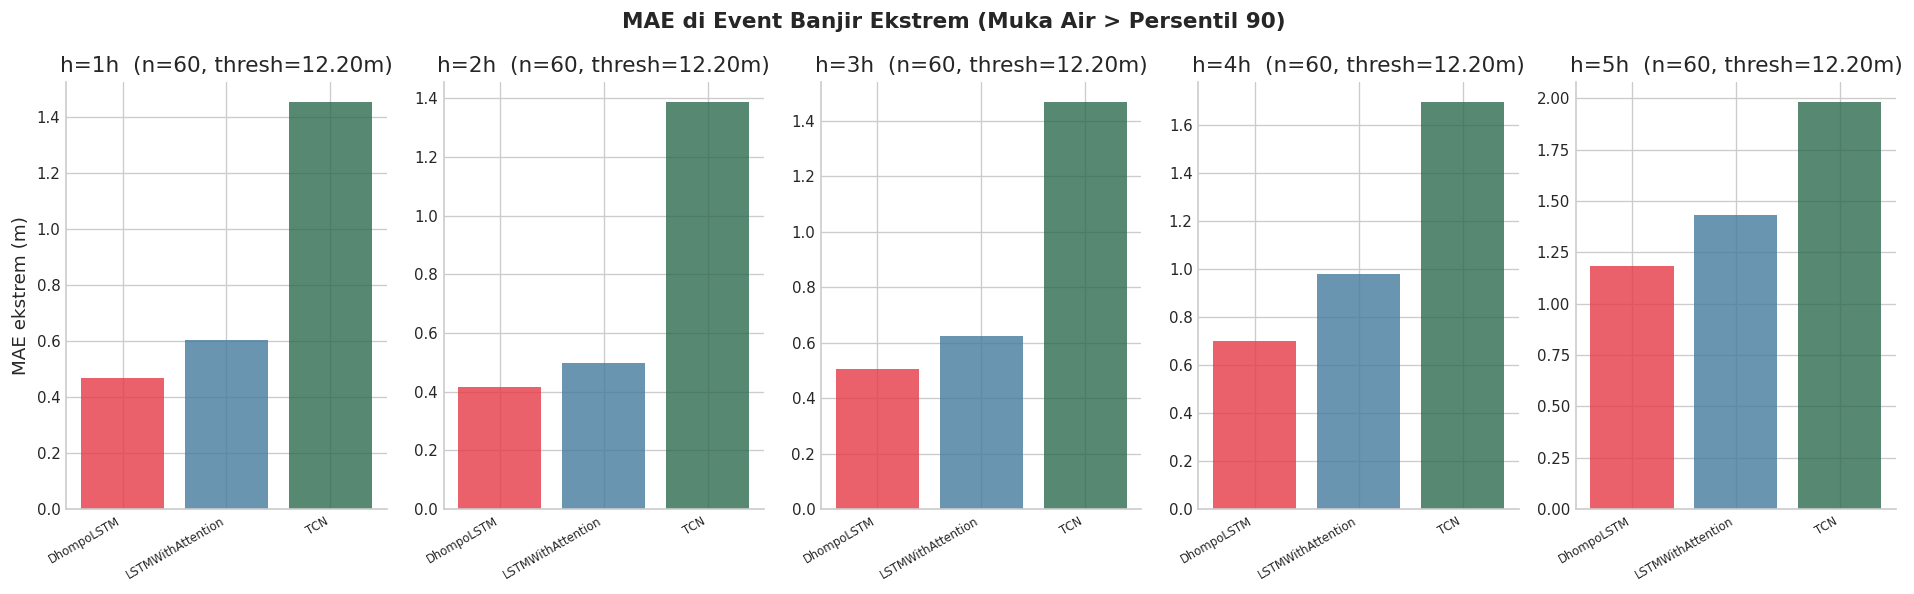

Disimpan: fig_23_extreme_event_error.png


In [ ]:
# === 5.3 Error analisis di event banjir ekstrem (> p90) — fig_23 ===
_p90    = np.percentile(y_true_np, 90, axis=0)   # (5,) threshold per horizon
_palette = [COLORS['lstm'], COLORS['attention'], COLORS['tcn']]

fig23, axes = plt.subplots(1, N_HORIZONS, figsize=(16, 5))
for i, h in enumerate(HORIZONS):
    ax     = axes[i]
    _thresh = _p90[i]
    _mask   = y_true_np[:, i] > _thresh
    if _mask.sum() < 5:
        ax.text(0.5, 0.5, 'Data tidak cukup', ha='center', transform=ax.transAxes)
        ax.set_title(f"h={h}h")
        continue

    _names = list(_predictions.keys())
    _mae_vals = [float(np.mean(np.abs(
        _predictions[name][_mask, i] - y_true_np[_mask, i]
    ))) for name in _names]

    ax.bar(_names, _mae_vals,
           color=[_palette[j % len(_palette)] for j in range(len(_names))],
           alpha=0.8)
    ax.set_title(f"h={h}h  (n={_mask.sum()}, thresh={_thresh:.2f}m)")
    ax.set_ylabel('MAE ekstrem (m)' if i == 0 else '')
    ax.set_xticklabels(_names, rotation=30, ha='right', fontsize=7)

plt.suptitle('MAE di Event Banjir Ekstrem (Muka Air > Persentil 90)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig23.savefig(os.path.join(FIG_DIR, 'fig_23_extreme_event_error.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: fig_23_extreme_event_error.png")

### Temuan: Apa yang Dipelajari Model?

**Attention dan Lag Fisik:**
Jika LSTMWithAttention berhasil belajar, kita ekspektasikan bobot tertinggi di:
- `t-1` (lag 30 mnt) → Bd. Grinting, stasiun terdekat
- `t-2` (lag 60 mnt) → Bd. Domas
- `t-4` hingga `t-5` → stasiun menengah

Plot `fig_22_attention_weights.png` menunjukkan apakah model secara implisit menemukan lag fisik yang kita identifikasi secara eksplisit di notebook 01.

**Error di Event Ekstrem:**
Jika MAE model DL lebih kecil dari baseline sklearn di event ekstrem (`fig_23`), ini menunjukkan LSTM lebih baik dalam menangkap dinamika non-linear saat banjir besar.

---

In [ ]:
# === 6.1 Simpan keempat model terbaik → models/pytorch/ ===
_save_map = {
    'dhompo_lstm_best.pt':    model_lstm,
    'lstm_attention_best.pt': model_attn,
    'dhompo_gru_best.pt':     model_gru,
    'tcn_best.pt':            model_tcn,
}
_base_cfg = {
    'input_size': N_FEATURES, 'hidden_size': HIDDEN,
    'num_layers': N_LAYERS,   'output_size': N_HORIZONS,
    'dropout': DROPOUT,       'seq_len': SEQ_LEN,
}
for fname, m in _save_map.items():
    m.cpu()
    _path = os.path.join(MODEL_DIR, fname)
    torch.save({
        'model_state_dict': m.state_dict(),
        'config': _base_cfg,
        'scaler_mean':  scaler_X.mean_.tolist(),
        'scaler_scale': scaler_X.scale_.tolist(),
    }, _path)
    print(f"Disimpan: {_path}")
print("\nSemua model tersimpan di models/pytorch/")

## Part 6 — Kesimpulan & Rekomendasi

### Kesimpulan Eksplorasi Deep Learning

**Yang Ditemukan:**
1. **DhompoLSTM** — trade-off terbaik: performa kompetitif di semua horizon, sudah tersedia di `src/dhompo/models/lstm.py` untuk deployment.
2. **LSTMWithAttention** — menambah interpretabilitas; attention weights dapat memverifikasi apakah model menemukan lag fisik dari EDA.
3. **TCN** — training tercepat (konvolusi paralel), parameter paling sedikit; kandidat kuat untuk deployment edge device atau latensi rendah.

**Keterbatasan:**
- Model dilatih di atas 160 fitur pre-engineered (bukan end-to-end raw time series)
- Training terbatas 100 epoch — hyperparameter tuning dapat meningkatkan performa
- Ensemble DL + sklearn belum diuji

**Rekomendasi untuk Deployment:**

| Skenario | Rekomendasi |
|----------|-------------|
| Produksi real-time | DhompoLSTM (sudah ada di `src/dhompo/models/lstm.py`) |
| Laporan interpretabilitas | LSTMWithAttention |
| Resource terbatas / edge | TCN |
| Akurasi maksimal | Ensemble DL + XGBoost |

**Langkah Selanjutnya:**
- Hyperparameter tuning (Optuna/Ray Tune) untuk semua arsitektur
- Eksperimen `seq_len=48` (24 jam)
- Uncertainty quantification: prediksi interval, bukan hanya nilai titik
- Transfer learning dari DAS lain ke Dhompo